In [4]:
from sdpm.experiments.points_ablation import do_experiment, draw_figure
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sdpm.experiments.util import RC_PARAMS
from sdpm.naming import get_metric_name
import pandas as pd
import seaborn as sns
from tqdm import tqdm
from sdpm.loader import load_model_from_config
from sdpm.util import score
from time import time
import json
import torch

In [5]:
DEVICE = "cuda:1"
points_n = [128, 256, 512, 1024, 2048, 4096, 8192, 8192 * 2, 8192 * 4]

In [6]:
def get_run_params(ds_name):
    config_row = df_all_results.query(f"ds_name == '{ds_name}' and model_name == 'sdpm_mlp'")
    params = config_row['params'].iloc[0]
    fold_seed = config_row['fold_seed'].iloc[0]
    return json.loads(params), int(fold_seed)

def get_ds(ds_name, seed):
    skf = StratifiedKFold(
        n_splits=4,
        shuffle=True,
        random_state=seed
    )
    data_path = f'data/{ds_name}.npz'
    data = np.load(data_path)
    y = data['y']
    X_num = data['X_num']
    X_cat = data['X_cat']
    train_idx, test_idx = next(skf.split(X_num, y["event"]))
    X_num_train, X_cat_train, y_train = X_num[train_idx], X_cat[train_idx], y[train_idx]
    X_num_test, X_cat_test, y_test = X_num[test_idx], X_cat[test_idx], y[test_idx]
    train_idx, val_idx = train_test_split(
        np.arange(y_train.shape[0]),
        test_size=0.25,
        stratify=y_train["event"],
        random_state=seed,
    )

    X_num_ptrain, X_num_pval = X_num_train[train_idx], X_num_train[val_idx]
    X_cat_ptrain, X_cat_pval = X_cat_train[train_idx], X_cat_train[val_idx]
    y_ptrain, y_pval = y_train[train_idx], y_train[val_idx]
    
    data_splits = {
        'X_num_train': X_num_ptrain,
        'X_cat_train': X_cat_ptrain,
        'y_train': y_ptrain,
        'X_num_val': X_num_pval,
        'X_cat_val': X_cat_pval,
        'y_val': y_pval,
        'X_num_test': X_num_test,
        'X_cat_test': X_cat_test,
        'y_test': y_test,
    }
    data.close()
    return data_splits


df_all_results = pd.read_csv("sdpm/experiments/results/final_results.csv", sep=";")

In [12]:
def do_experiment(data: dict,
                  config: dict,
                  iterations: int,
                  points_grid,
                  device: str = DEVICE,
                 seed: int = 42, batch_size = 32768):
    val_set = (
        data['X_num_val'],
        data['X_cat_val'],
        data['y_val']
    )
    bar = tqdm(range(iterations))
    result = {
        'time': np.zeros((iterations, len(points_grid))),
        'ibs': np.zeros((iterations, len(points_grid))),
        'auc': np.zeros((iterations, len(points_grid))),
        'c_index': np.zeros((iterations, len(points_grid)))
    }
    model_name = 'sdpm_mlp'
    model = load_model_from_config(model_name, config,
                                    device=device,
                                    X_num_train=data['X_num_train'],
                                    X_cat_train=data['X_cat_train'],
                                    y_train=data['y_train'],
                                  seed=seed)
    model.fit(X_num=data['X_num_train'],
              X_cat=data['X_cat_train'],
              y=data['y_train'],
              val_set=val_set)
    gen = np.random.default_rng(seed=seed)
    for i in bar:
        for j, p in enumerate(points_grid):
            bar.set_description(f'{p} points')
            time_start = time()
            c_index, ibs, auc = model.score(X_num=data['X_num_test'],
                                            X_cat=data['X_cat_test'],
                                            y=data['y_test'],
                                            times_n=p, seed=gen.integers(1, 2 ** 20, 1).item())
            result['time'][i, j] = time() - time_start
            result['c_index'][i, j] = c_index
            result['auc'][i, j] = auc
            result['ibs'][i, j] = ibs
    return result

In [13]:
ds_name = 'vlbw'
config, seed = get_run_params(ds_name)
config['val_metric'] = 'ibs'
data = get_ds(ds_name, seed)
iter_n = 100

In [14]:
results_time = do_experiment(data, config, iter_n, points_n, DEVICE, seed, batch_size=32768 * 32)

32768 points: 100%|███████████████████████████████████████████████████████| 100/100 [1:29:23<00:00, 53.63s/it]


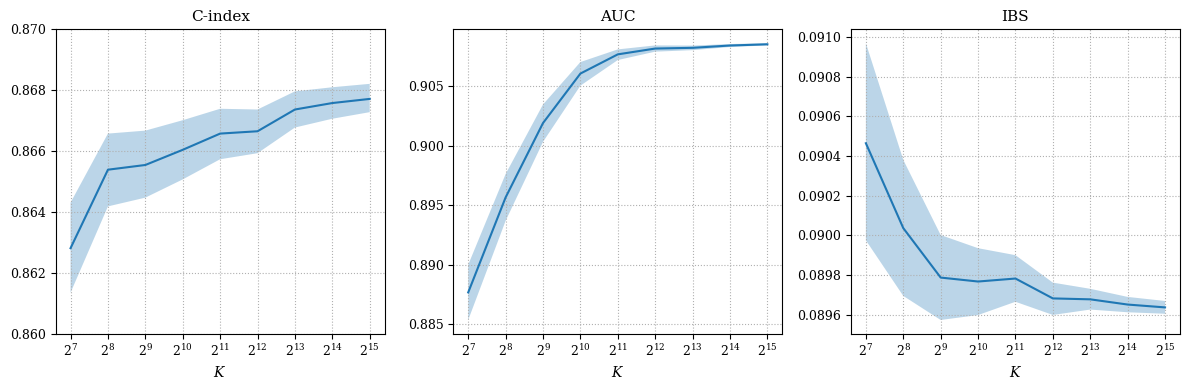

In [16]:
points_grid = points_n
log_scale = True
results = results_time

with plt.rc_context(RC_PARAMS):
    fig, axes = plt.subplots(1, 3, sharex=True, figsize=(12, 4))
    for i, k in enumerate(['c_index', 'auc', 'ibs']):
        ax = axes[i]
        mean = np.mean(results[k], axis=0)
        
        # p_min, p_max = np.percentile(results_rotterdam[k], (5, 95), axis=0)
        # p_min, p_max = mean - np.std(results_rotterdam[k], axis=0), mean + np.std(results_rotterdam[k], axis=0)
        p_min = np.zeros(results[k].shape[1])
        p_max = np.zeros(results[k].shape[1])
        for j in range(results[k].shape[1]):
            cur_arr = results[k][:, j]
            bootstrap_means = [np.mean(np.random.choice(cur_arr, size=results[k].shape[0], replace=True)) for _ in range(10000)]
            p_min_cur, p_max_cur = np.percentile(bootstrap_means, [2.5, 97.5])
            p_min[j] = p_min_cur
            p_max[j] = p_max_cur
        
        ax.plot(points_grid, mean)
        ax.fill_between(points_grid, p_min, p_max, alpha=0.3)
        ax.set_xticks(points_grid)
        ax.grid(ls=':')
        # ax.set_ylabel(get_metric_name(k))
        ax.set_xlabel('$K$')
        ax.set_title(get_metric_name(k))
        # fig.suptitle('TCGA-GBM')
        if log_scale:
            ax.set_xscale("log", base=2)
            ax.set_xticks(points_grid)
    axes[0].set_ylim(0.86, 0.87)
    plt.tight_layout()
    plt.show()

In [17]:
fig.savefig('ablation_time_points_vlbw.png', dpi=300)

In [16]:
np.mean(results['time'], axis=0)

array([ 0.21371868,  0.3804075 ,  0.73292844,  1.43852544,  2.83611747,
        5.60668046, 11.21142265, 22.31656293, 44.78621727])

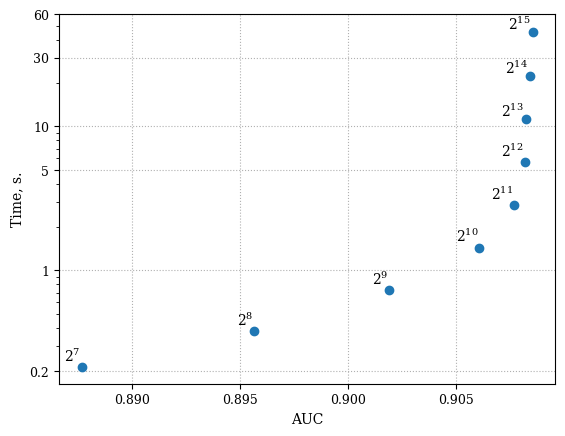

In [20]:
with plt.rc_context(RC_PARAMS):
    fig, ax = plt.subplots()
    mean_metric = np.mean(results['auc'], axis=0)
    mean_time = np.mean(results['time'], axis=0)
    ax.scatter(mean_metric, mean_time, zorder=1000)
    # ax.scatter(mean_c_index_rotterdam, mean_time_rotterdam, zorder=1000, label='Rotterdam')
    for i, (x, y, text) in enumerate(zip(mean_metric, mean_time, [f"$2^{{{i}}}$" for i in range(7, 16)])):
        if i >= len(mean_metric) - 3:
            ax.text(x - 0.0001, y, text, horizontalalignment='right', verticalalignment='bottom')
        else:
            ax.text(x - 0.00005, y * 1.05, text, horizontalalignment='right', verticalalignment='bottom')
    ax.grid(ls=':')
    # ax.set_ylim(top=65, bottom=np.min(mean_time) * 0.9)
    ax.set_yscale("log", base=10)
    yticks = [0.2, 1, 5, 10, 30, 60]
    ax.set_yticks(yticks, labels=[str(t) for t in yticks])
    ax.set_ylabel('Time, s.')
    ax.set_xlabel('AUC')
    # fig.savefig('time_ablation.png', dpi=300)
    plt.show()

In [21]:
fig.savefig('ablation_inference_time.png', dpi=300)